In [23]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import os

import oggm
from oggm import cfg, utils, workflow, tasks, graphics
from oggm.core import massbalance
from oggm.core.massbalance import mb_calibration_from_scalar_mb, mb_calibration_from_geodetic_mb, mb_calibration_from_wgms_mb

In [24]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-mb', reset=True)
cfg.PARAMS['border'] = 10

2024-10-22 16:05:52: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2024-10-22 16:05:52: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2024-10-22 16:05:52: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2024-10-22 16:05:52: oggm.cfg: PARAMS['border'] changed from `80` to `10`.


In [25]:
# we start from preprocessing level 3
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5/'
gdirs = workflow.init_glacier_directories(['RGI60-06.00291'], from_prepro_level=3, prepro_base_url=base_url)

2024-10-22 16:05:53: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2024-10-22 16:05:53: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [26]:
gdirs

[<oggm.GlacierDirectory>
   RGI id: RGI60-06.00291
   Region: 06: Iceland
   Subregion: 06-01: Iceland                         
   Name: Hagafellsjoekull West
   Glacier type: Ice cap
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 126.529 km2
   Lon, Lat: (-20.4355, 64.571)
   Grid (nx, ny): (96, 114)
   Grid (dx, dy): (167.0, -167.0)]

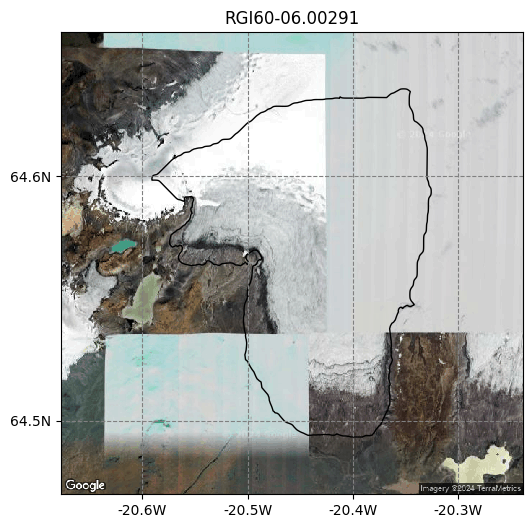

In [40]:
f, ax = plt.subplots(1,1,figsize=(6, 6))
graphics.plot_googlemap(gdirs[:2], ax=ax)
ax.set_title(gdirs[0].rgi_id);

In [41]:
gdir_kwf = gdirs[0]  # Note: Correctly using gdir_kwf  

In [42]:
gdir_kwf.get_climate_info() 

{'baseline_climate_source': 'GSWP3_W5E5',
 'baseline_yr_0': 1901,
 'baseline_yr_1': 2019,
 'baseline_climate_ref_hgt': 864.0,
 'baseline_climate_ref_pix_lon': -20.25,
 'baseline_climate_ref_pix_lat': 64.75}

In [44]:
# Example of reading JSON from the glacier directory object  
# Make sure gdir_kwf is the correct instance and is not a string  
gdir_kwf.read_json('mb_calib')

{'rgi_id': 'RGI60-06.00291',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 2.978871337642207,
 'temp_bias': -1.387045320120482,
 'reference_mb': -1610.5,
 'reference_mb_err': 133.70000000000002,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

In [73]:
for gdir in gdirs:
    mbmod = massbalance.MonthlyTIModel(gdir)
    mean_mb = mbmod.get_specific_mb(fls=gdir.read_pickle('inversion_flowlines'),
                                               year=np.arange(2000,2020,1)).mean()
    print(gdir.rgi_id, f': average MB 2000-2020 = {mean_mb:.1f} kg m-2, ',
          f"prcp_fac: {gdir.read_json('mb_calib')['prcp_fac']:.2f}")

RGI60-06.00291 : average MB 2000-2020 = -1610.5 kg m-2,  prcp_fac: 2.98


In [78]:
gdir_kwf.read_json('mb_calib')['mb_global_params']

{'temp_default_gradient': -0.0065,
 'temp_all_solid': 0.0,
 'temp_all_liq': 2.0,
 'temp_melt': -1.0}

In [80]:
h, w = gdir_kwf.get_inversion_flowline_hw()
mb_geod = massbalance.MonthlyTIModel(gdir_kwf)
# Note, if you change cfg.PARAMS['geodetic_mb_period'], you need to change the years here as well!
mbdf= pd.DataFrame(index = np.arange(2000,2020,1))
mbdf['mod_mb'] = mb_geod.get_specific_mb(h, w, year=mbdf.index)
mbdf.mean()

mod_mb   -1610.5
dtype: float64

In [81]:
print('reference MB: ' + str(gdir_kwf.read_json('mb_calib')['reference_mb'])+ ' kg m-2')
print('reference MB uncertainties: '+ str(gdir_kwf.read_json('mb_calib')['reference_mb_err'])+ ' kg m-2')
print('reference MB time period: ' + gdir_kwf.read_json('mb_calib')['reference_period'])

reference MB: -1610.5 kg m-2
reference MB uncertainties: 133.70000000000002 kg m-2
reference MB time period: 2000-01-01_2020-01-01


In [83]:
# this tests if the two parameters are very similar:
np.testing.assert_allclose(gdir_kwf.read_json('mb_calib')['reference_mb'], mbdf['mod_mb'].mean())

NameError: name 'ref_mb' is not defined

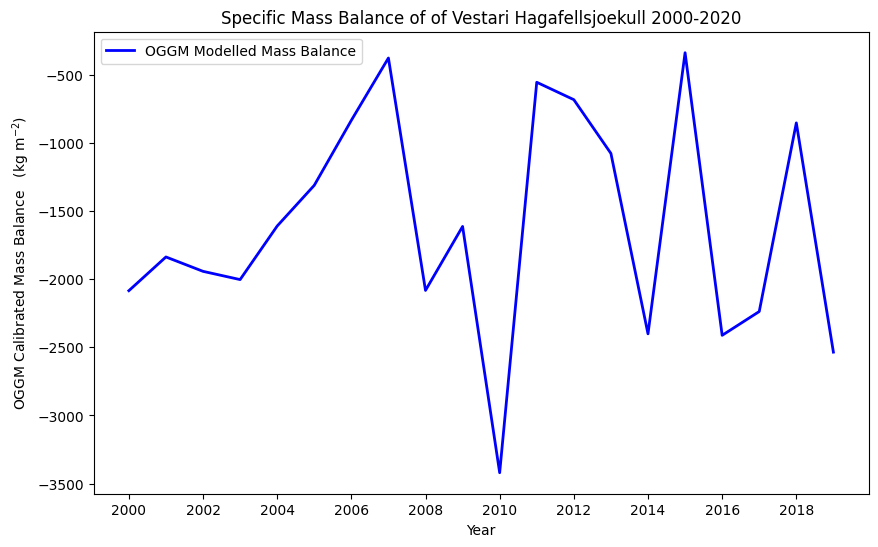

In [96]:
# Create a new figure for the line chart
plt.figure(figsize=(10, 6))

# Plot 'mod_mb' data from the mbdf DataFrame
plt.plot(mbdf.index, mbdf['mod_mb'], label='OGGM Modelled Mass Balance', color='b', lw=2)

# Customize the x-axis ticks and labels (assuming the years are in the index)
plt.xticks(np.arange(2000, 2020, 2))

# Labels for the axes
plt.xlabel('Year')
plt.ylabel('OGGM Calibrated Mass Balance   (kg m$^{-2}$)')

# Add a title to the chart
plt.title('Specific Mass Balance of of Vestari Hagafellsjoekull 2000-2020')

# Show the legend
plt.legend()